In [2]:
import pandas as pd
import numpy as np

	•	vi vill undersöka vad som påverkar Airbnb-priser i Stockholm
	•	vi vill bygga en modell som uppskattar ett rimligt pris
	•	vi vill jämföra verkligt pris mot modellens förväntade pris

In [11]:
df = pd.read_csv("data/airbnb_listings_stockholm_detailed.csv")

print(df.shape)
df.head()

(4955, 79)


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,164448,https://www.airbnb.com/rooms/164448,20250929042406,2025-09-29,city scrape,Double room in central Stockholm with Wi-Fi,I am renting out a nice double room on the top...,NaN,https://a0.muscache.com/pictures/f56d8d10-a7fa...,784312,...,4.97,4.84,4.76,NaN,f,2,0,2,0,2.63
1,220851,https://www.airbnb.com/rooms/220851,20250929042406,2025-09-29,city scrape,One room in appartement,Welcome!,Many restaurangs wery close and walkingdistanc...,https://a0.muscache.com/pictures/2085606/7a706...,412283,...,4.88,4.82,4.71,NaN,f,2,1,1,0,0.39
2,238411,https://www.airbnb.com/rooms/238411,20250929042406,2025-09-29,city scrape,Cozy apartment in central Stockholm,NaN,"Restaurants, cafés, museums, art galleries, pa...",https://a0.muscache.com/pictures/2806060/7fc68...,1250232,...,4.95,4.85,4.64,NaN,f,1,1,0,0,0.65
3,242188,https://www.airbnb.com/rooms/242188,20250929042406,2025-09-29,city scrape,Single room in central Stockholm with Wi-Fi,I am renting out a nice single room on the top...,NaN,https://a0.muscache.com/pictures/2303148/55d1e...,784312,...,4.97,4.89,4.83,NaN,f,2,0,2,0,2.68
4,273906,https://www.airbnb.com/rooms/273906,20250929042406,2025-09-29,city scrape,Penthouse in central Stockholm,NaN,NaN,https://a0.muscache.com/pictures/2881091/f5404...,1432722,...,4.75,5.00,5.00,NaN,f,2,2,0,0,0.02


In [12]:
#Gör en kopia med bara de kolumner jag vill jobba med
df = df[[
    "name",
    "listing_url",
    "price",
    "accommodates",
    "bedrooms",
    "beds",
    "bathrooms",
    "property_type",
    "room_type",
    "neighbourhood_cleansed",
    "review_scores_rating",
    "number_of_reviews",
    "availability_365",
    "minimum_nights"
]].copy()

print(df.shape)
df.head()

(4955, 14)


,name,listing_url,price,accommodates,bedrooms,beds,bathrooms,property_type,room_type,neighbourhood_cleansed,review_scores_rating,number_of_reviews,availability_365,minimum_nights
0,Double room in central Stockholm with Wi-Fi,https://www.airbnb.com/rooms/164448,$917.00,2,1.0,2.0,1.0,Private room in rental unit,Private room,Södermalms,4.86,454,169,2
1,One room in appartement,https://www.airbnb.com/rooms/220851,$450.00,1,1.0,1.0,1.0,Private room in rental unit,Private room,Kungsholmens,4.69,66,296,2
2,Cozy apartment in central Stockholm,https://www.airbnb.com/rooms/238411,"$1,073.00",2,1.0,2.0,1.0,Entire rental unit,Entire home/apt,Norrmalms,4.79,110,79,1
3,Single room in central Stockholm with Wi-Fi,https://www.airbnb.com/rooms/242188,$779.00,1,1.0,1.0,1.0,Private room in rental unit,Private room,Södermalms,4.90,444,168,2
4,Penthouse in central Stockholm,https://www.airbnb.com/rooms/273906,"$2,352.00",4,3.0,3.0,2.0,Entire rental unit,Entire home/apt,Södermalms,5.00,4,271,6


In [13]:
#Rena pris
df["price"] = (
    df["price"]
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .astype(float)
)

df["price"].describe()

count      3190.000000
mean       1690.473041
std        3704.741906
min         120.000000
25%         753.000000
50%        1200.000000
75%        2000.000000
max      112218.000000
Name: price, dtype: float64

In [14]:
df["price"].head(10)

0     917.0
1     450.0
2    1073.0
3     779.0
4    2352.0
5    1126.0
6     950.0
7     751.0
8    4300.0
9    1218.0
Name: price, dtype: float64

In [15]:
upper = df["price"].quantile(0.99)

df = df[df["price"] <= upper].copy()

df["price"].describe()

count    3158.000000
mean     1502.045598
std      1061.893191
min       120.000000
25%       750.000000
50%      1195.500000
75%      1980.000000
max      6750.000000
Name: price, dtype: float64

Visuell representation av kapacitet efters kvm inte finns, bara beds, bedrooms och boendeplatser

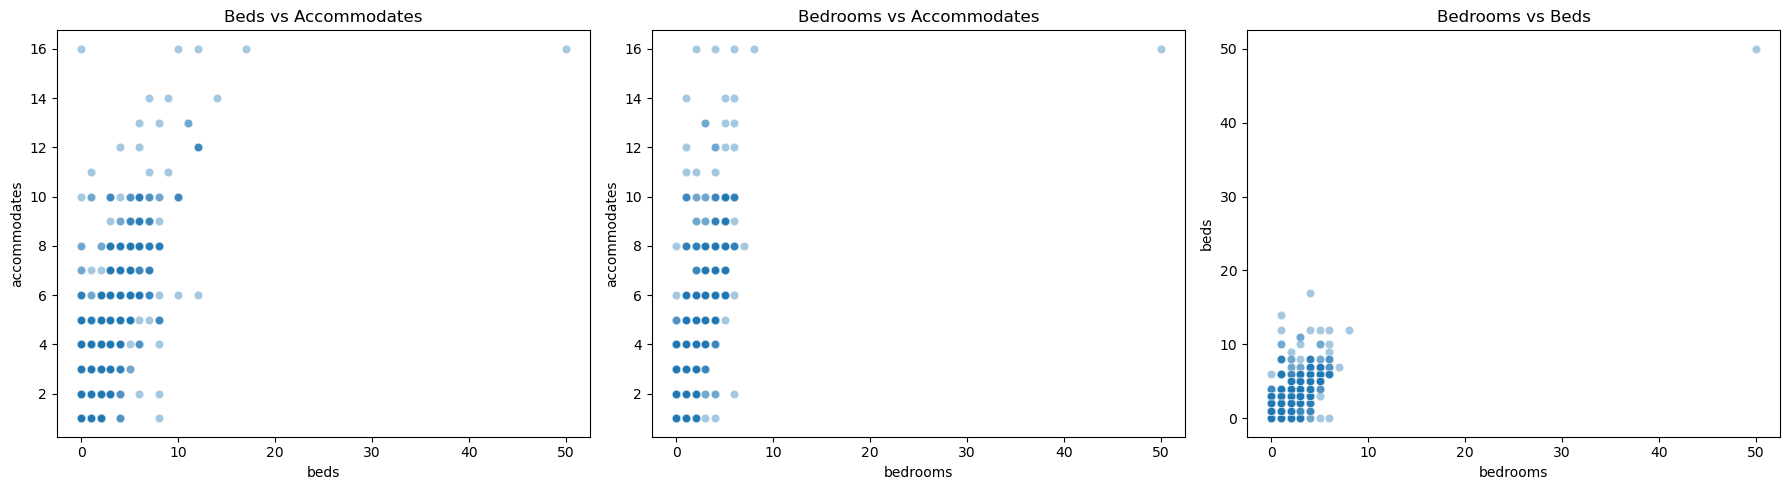

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.scatterplot(data=df, x="beds", y="accommodates", alpha=0.4, ax=axes[0])
axes[0].set_title("Beds vs Accommodates")

sns.scatterplot(data=df, x="bedrooms", y="accommodates", alpha=0.4, ax=axes[1])
axes[1].set_title("Bedrooms vs Accommodates")

sns.scatterplot(data=df, x="bedrooms", y="beds", alpha=0.4, ax=axes[2])
axes[2].set_title("Bedrooms vs Beds")

plt.tight_layout()
plt.show()

Man ser att några punkter är knas så tar bort dem.

In [17]:
df = df[
    (df["accommodates"] <= 10) &
    (df["bedrooms"] <= 10) &
    (df["beds"] <= 15)
].copy()

df[["accommodates", "bedrooms", "beds"]].describe()

,accommodates,bedrooms,beds
count,3124.000000,3124.000000,3124.000000
mean,3.431498,1.579385,2.093150
std,1.903898,1.140654,1.489841
min,1.000000,0.000000,0.000000
25%,2.000000,1.000000,1.000000
50%,3.000000,1.000000,2.000000
75%,4.000000,2.000000,3.000000
max,10.000000,7.000000,12.000000


Leta efter tomma värden

In [18]:
df.isna().sum()

name                        0
listing_url                 0
price                       0
accommodates                0
bedrooms                    0
beds                        0
bathrooms                   1
property_type               0
room_type                   0
neighbourhood_cleansed      0
review_scores_rating      499
number_of_reviews           0
availability_365            0
minimum_nights              0
dtype: int64

In [19]:
# 1. Bathrooms (bara 1 värde saknas → median)
df["bathrooms"] = df["bathrooms"].fillna(df["bathrooms"].median())

# 2. Skapa has_rating (innan vi fyller för att inte tappa dem som faktiskt hade ratings)
df["has_rating"] = df["review_scores_rating"].notnull().astype(int)

# 3. Fyll rating med median för att kunna köra modellberäkningar
df["review_scores_rating"] = df["review_scores_rating"].fillna(
    df["review_scores_rating"].median()
)

# Kontroll
df.isna().sum()

name                      0
listing_url               0
price                     0
accommodates              0
bedrooms                  0
beds                      0
bathrooms                 0
property_type             0
room_type                 0
neighbourhood_cleansed    0
review_scores_rating      0
number_of_reviews         0
availability_365          0
minimum_nights            0
has_rating                0
dtype: int64

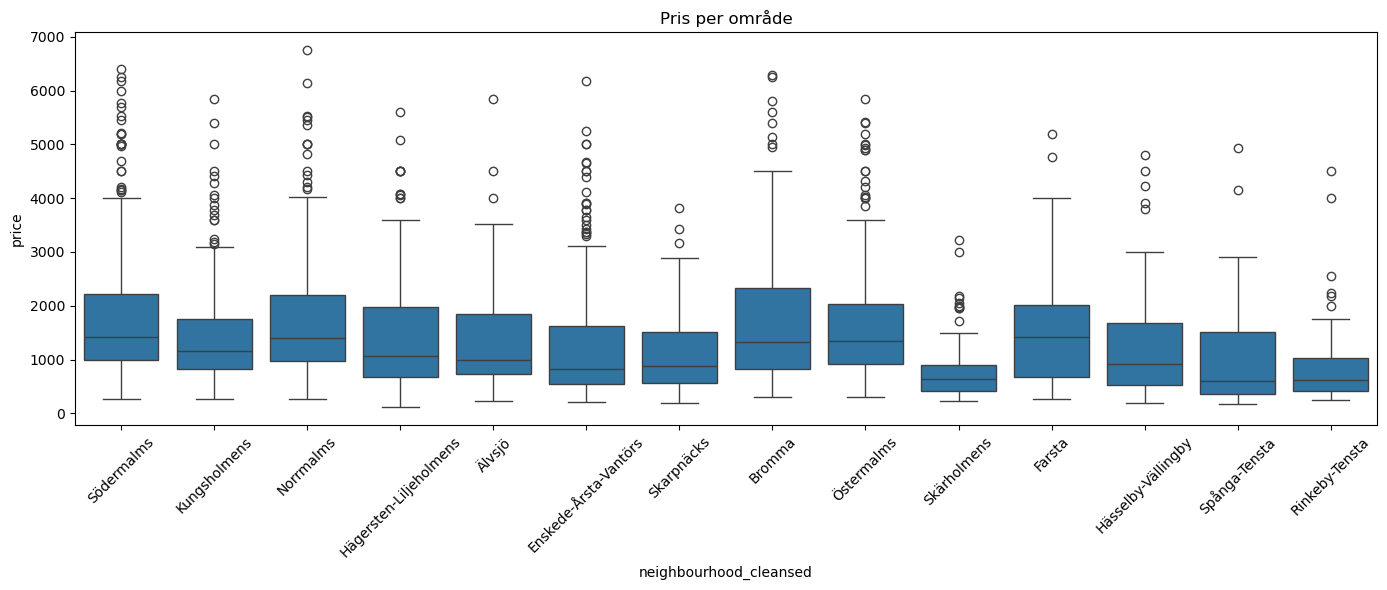

In [20]:
plt.figure(figsize=(14, 6))

sns.boxplot(
    data=df,
    x="neighbourhood_cleansed",
    y="price"
)

plt.xticks(rotation=45)
plt.title("Pris per område")
plt.tight_layout()
plt.show()

Analysen visar att vissa ytterområden, såsom Farsta och Bromma, uppvisar liknande prisnivåer som innerstaden.

Detta indikerar att prisvariation inte enbart kan förklaras av geografiskt läge, utan även påverkas starkt av boendetyp och storlek. Låt oss undersöka det.

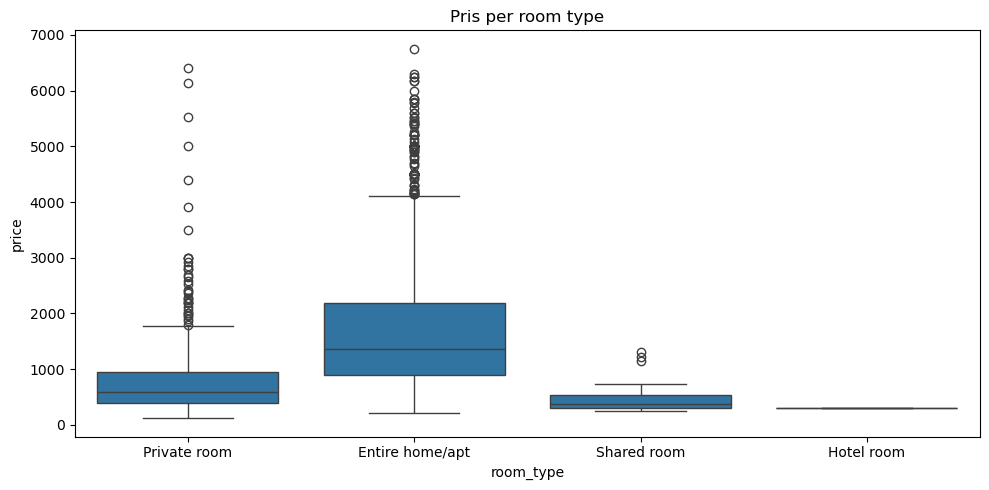

In [21]:
plt.figure(figsize=(10, 5))

sns.boxplot(
    data=df,
    x="room_type",
    y="price"
)

plt.title("Pris per room type")
plt.tight_layout()
plt.show()

In [22]:
df = df[df["room_type"] != "Hotel room"].copy()

Tydligt att room_type spelar roll för pris. Nu vill jag kolla property_typ

In [23]:
df["property_type"].value_counts()

property_type
Entire rental unit                    1711
Private room in rental unit            368
Entire home                            315
Entire condo                           185
Entire villa                            90
Room in hotel                           51
Private room in home                    48
Private room in condo                   47
Entire townhouse                        47
Entire serviced apartment               28
Private room in bed and breakfast       26
Private room in hostel                  26
Entire loft                             22
Room in aparthotel                      21
Tiny home                               21
Entire guesthouse                       20
Private room in villa                   12
Private room in townhouse               10
Room in boutique hotel                  10
Entire cabin                             9
Entire guest suite                       8
Shared room in hotel                     7
Shared room in hostel                   

Property_group är kanske användbar men den är spretig som fan, så, vi kokar ner den.

In [26]:
def simplify_property_type(x):
    x = x.lower()

    # specialfall
    if "boat" in x or "camper" in x:
        return "unique"

    # apartment-typer
    elif any(word in x for word in [
        "rental unit",
        "apartment",
        "condo",
        "loft",
        "serviced apartment",
        "aparthotel"
    ]):
        return "apartment"

    # resten = house
    else:
        return "house"


df["property_group"] = df["property_type"].apply(simplify_property_type)

df["property_group"].value_counts()


property_group
apartment    2392
house         723
unique          8
Name: count, dtype: int64

In [27]:
df["room_type"].value_counts()

room_type
Entire home/apt    2488
Private room        613
Shared room          22
Name: count, dtype: int64

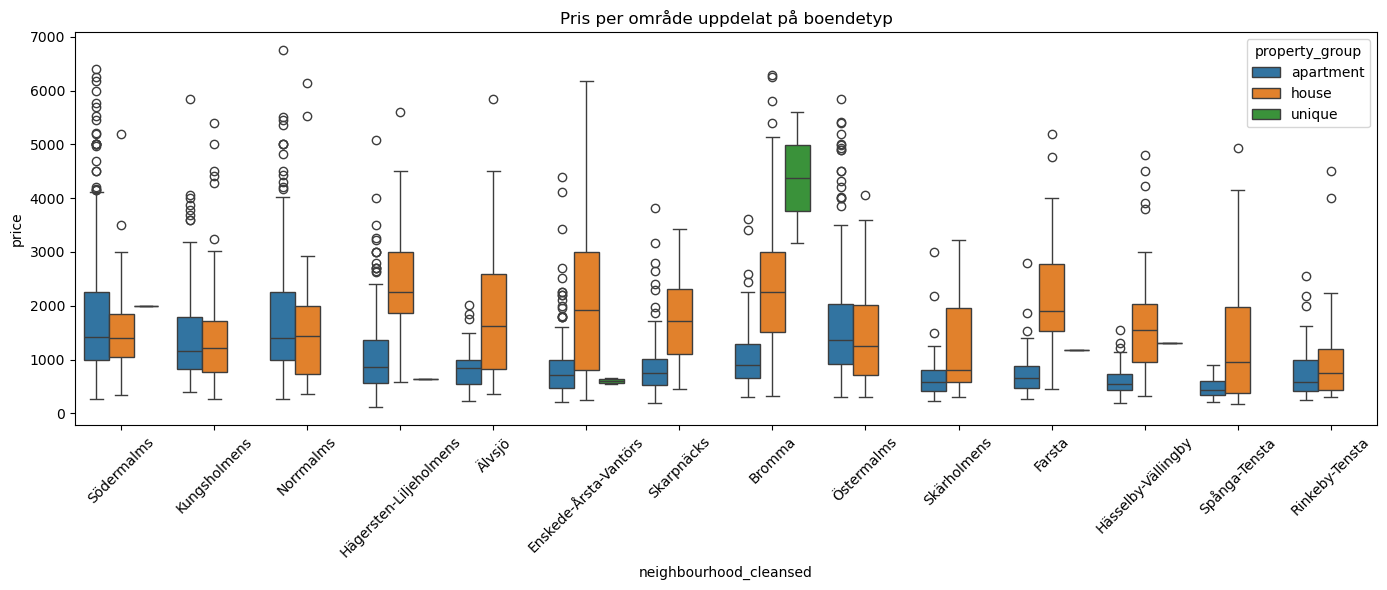

In [28]:
plt.figure(figsize=(14, 6))

sns.boxplot(
    data=df,
    x="neighbourhood_cleansed",
    y="price",
    hue="property_group"
)

plt.xticks(rotation=45)
plt.title("Pris per område uppdelat på boendetyp")
plt.tight_layout()
plt.show()

När priset bryts ned efter både område och boendetyp framträder en tydlig förklaring till de tidigare observerade mönstren.

I områden som Farsta och Bromma drivs de högre prisnivåerna i stor utsträckning av större boenden, såsom hus. Lägenheter i samma områden ligger däremot på betydligt lägre nivåer.

Detta visar att skillnader i pris mellan områden till stor del kan förklaras av variation i boendetyp snarare än enbart geografiskt läge.

Jag har ett dilemma, shared rooms. De stör i modellen för de är så mycket lägre i pris och vad innebär shared ens? Kollar in dem:

In [29]:
shared = df[df["room_type"] == "Shared room"].copy()

shared[[
    "name",
    "listing_url",
    "price",
    "accommodates",
    "beds",
    "property_type",
    "neighbourhood_cleansed"
]].sort_values("price")

,name,listing_url,price,accommodates,beds,property_type,neighbourhood_cleansed
4494,1 bed space available in a room,https://www.airbnb.com/rooms/1420495607670465424,244.0,1,2.0,Shared room in rental unit,Spånga-Tensta
4179,A bed in a Female 6 dorm room,https://www.airbnb.com/rooms/1325128355576588944,269.0,6,6.0,Shared room in hotel,Kungsholmens
4180,A bed in a Mixed 6-bed dorm room,https://www.airbnb.com/rooms/1325159022847500364,269.0,6,6.0,Shared room in hotel,Kungsholmens
4183,A bed in an Mixed 8 bed dorm room,https://www.airbnb.com/rooms/1325174269976835966,269.0,8,8.0,Shared room in hotel,Kungsholmens
4184,A bed in a Mixed 4 bed dorm room,https://www.airbnb.com/rooms/1325176930870790184,269.0,4,4.0,Shared room in hotel,Kungsholmens
3160,Shared 6 Bed Mixed Dorm Room,https://www.airbnb.com/rooms/1076079717724966711,299.0,6,6.0,Shared room in hostel,Östermalms
3193,Shared 10 Bed Mixed Dorm Room,https://www.airbnb.com/rooms/1084779951646918950,300.0,10,10.0,Shared room in hostel,Östermalms
3192,Shared 8 Bed Mixed Dorm Room,https://www.airbnb.com/rooms/1084771285496305626,309.0,8,8.0,Shared room in hostel,Östermalms
866,Bunk bed in shared room close to Älvsjö exhibit,https://www.airbnb.com/rooms/25544986,350.0,2,2.0,Shared room in home,Enskede-Årsta-Vantörs
4871,Generator - Bed in 6 Bed Dorm,https://www.airbnb.com/rooms/1497168341323390909,355.0,1,1.0,Shared room in hotel,Norrmalms


Nu ser man att shared rooms är sängar i sovsalar på hostels typ. Inte rättvist ha med dessa i modellen som jämför lägenhet/hus-priser. Jag tar bort dem i datan innan jag gör modellen.

In [30]:
df = df[df["room_type"] != "Shared room"].copy()

df["room_type"].value_counts()

room_type
Entire home/apt    2488
Private room        613
Name: count, dtype: int64

In [31]:
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np

# ===== 1. Kopiera din rensade data =====
cleandf = df.copy()

# ===== 2. One-hot encode (EXAKT Emil) =====
cleandf = pd.get_dummies(
    cleandf,
    columns=["room_type", "neighbourhood_cleansed"],
    drop_first=True
)

# ===== 3. Hitta dummy-kolumner =====
neighbourhood_dummies = [col for col in cleandf.columns if col.startswith("neighbourhood_cleansed_")]
room_dummies = [col for col in cleandf.columns if col.startswith("room_type_")]

# ===== 4. Features =====
features = [
    "accommodates",
    "bedrooms",
    "beds",
    "bathrooms",
    "review_scores_rating",
    "number_of_reviews",
    "availability_365",
    "minimum_nights",
    "has_rating"
] + neighbourhood_dummies + room_dummies

# ===== 5. Target (log) =====
cleandf["log_price"] = np.log1p(cleandf["price"])

X = cleandf[features].astype(float)
y = cleandf["log_price"]

# ===== 6. Train/test =====
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train_sm = sm.add_constant(X_train)
X_test_sm = sm.add_constant(X_test)

# ===== 7. Modell =====
model_emil = sm.OLS(y_train, X_train_sm).fit()

# ===== 8. Prediktion =====
y_pred = model_emil.predict(X_test_sm)

# ===== 9. Utvärdering =====
r2_train = r2_score(y_train, model_emil.predict(X_train_sm))
r2_test = r2_score(y_test, y_pred)

mae_log = mean_absolute_error(y_test, y_pred)
mae_sek = mean_absolute_error(np.expm1(y_test), np.expm1(y_pred))

print("=== EMIL MODELL ===")
print(f"R² träning: {r2_train:.3f}")
print(f"R² test:    {r2_test:.3f}")
print(f"MAE (log):  {mae_log:.3f}")
print(f"MAE (SEK):  {mae_sek:.0f} kr")

=== EMIL MODELL ===
R² träning: 0.626
R² test:    0.619
MAE (log):  0.328
MAE (SEK):  484 kr


Efter datarening förbättrades modellens prestanda avsevärt. R²-värdet ökade till cirka 0.62 och det genomsnittliga felet minskade till cirka 484 kronor per natt.

Detta indikerar att datakvalitet har stor betydelse för modellens förmåga att förklara prisvariationer.

Nu vill jag se om min nya variabel property_typ hjälper modellen!

In [32]:
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np

# ===== 1. Kopiera din rensade data =====
cleandf = df.copy()

# ===== 2. One-hot encode (Emil + din property_group) =====
cleandf = pd.get_dummies(
    cleandf,
    columns=["room_type", "neighbourhood_cleansed", "property_group"],
    drop_first=True
)

# ===== 3. Hitta dummy-kolumner =====
neighbourhood_dummies = [col for col in cleandf.columns if col.startswith("neighbourhood_cleansed_")]
room_dummies = [col for col in cleandf.columns if col.startswith("room_type_")]
property_dummies = [col for col in cleandf.columns if col.startswith("property_group_")]

# ===== 4. Features =====
features = [
    "accommodates",
    "bedrooms",
    "beds",
    "bathrooms",
    "review_scores_rating",
    "number_of_reviews",
    "availability_365",
    "minimum_nights",
    "has_rating"
] + neighbourhood_dummies + room_dummies + property_dummies

# ===== 5. Target (log) =====
cleandf["log_price"] = np.log1p(cleandf["price"])

X = cleandf[features].astype(float)
y = cleandf["log_price"]

# ===== 6. Train/test =====
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train_sm = sm.add_constant(X_train)
X_test_sm = sm.add_constant(X_test)

# ===== 7. Modell =====
model_you = sm.OLS(y_train, X_train_sm).fit()

# ===== 8. Prediktion =====
y_pred = model_you.predict(X_test_sm)

# ===== 9. Utvärdering =====
r2_train = r2_score(y_train, model_you.predict(X_train_sm))
r2_test = r2_score(y_test, y_pred)

mae_log = mean_absolute_error(y_test, y_pred)
mae_sek = mean_absolute_error(np.expm1(y_test), np.expm1(y_pred))

print("=== MIN MODELL ===")
print(f"R² träning: {r2_train:.3f}")
print(f"R² test:    {r2_test:.3f}")
print(f"MAE (log):  {mae_log:.3f}")
print(f"MAE (SEK):  {mae_sek:.0f} kr")

=== MIN MODELL ===
R² träning: 0.637
R² test:    0.635
MAE (log):  0.321
MAE (SEK):  471 kr


Den utökade modellen, som inkluderar en förenklad kategorisering av boendetyp (property_group), uppvisar en förbättrad förklaringsgrad och lägre prediktionsfel jämfört med grundmodellen.

Detta indikerar att skillnader i boendetyp, såsom lägenhet kontra hus, är en viktig faktor för att förklara prisvariationer och bör beaktas vid modellering.

In [33]:
# Lägg tillbaka prediction på hela datasetet
X_all = sm.add_constant(X, has_constant="add")

cleandf["predicted_log_price"] = model_you.predict(X_all)
cleandf["predicted_price"] = np.expm1(cleandf["predicted_log_price"])

# Skillnad
cleandf["diff"] = cleandf["price"] - cleandf["predicted_price"]
cleandf["pct_diff"] = (cleandf["diff"] / cleandf["predicted_price"]) * 100

In [37]:
deals_df = cleandf[
    (cleandf["room_type_Private room"] == 0) &   # Entire home/apt
    (cleandf["property_group_house"] == 0) &     # inte house
    (cleandf["property_group_unique"] == 0) &    # inte unique
    (cleandf["accommodates"] <= 6)
].copy()

Kopierar Emils Regressionsmodell men med property_type också

In [39]:
print("OLS1: Pris ~ accommodates")

X = sm.add_constant(cleandf[["accommodates"]])
y = cleandf["log_price"]

model1 = sm.OLS(y, X).fit()

print(model1.summary())

OLS1: Pris ~ accommodates
                            OLS Regression Results                            
Dep. Variable:              log_price   R-squared:                       0.379
Model:                            OLS   Adj. R-squared:                  0.378
Method:                 Least Squares   F-statistic:                     1888.
Date:                Wed, 15 Apr 2026   Prob (F-statistic):          1.63e-322
Time:                        13:05:53   Log-Likelihood:                -2459.6
No. Observations:                3101   AIC:                             4923.
Df Residuals:                    3099   BIC:                             4935.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const            6.336

In [42]:
print("OLS2: + neighbourhood")

neighbourhood_dummies = [col for col in cleandf.columns if col.startswith("neighbourhood_cleansed_")]

X = cleandf[["accommodates"] + neighbourhood_dummies].copy()
X = sm.add_constant(X).astype(float)

y = cleandf["log_price"].astype(float)

model2 = sm.OLS(y, X).fit()

print(model2.summary())
print(f"\nR² ökning: {model1.rsquared:.3f} → {model2.rsquared:.3f}")

OLS2: + neighbourhood
                            OLS Regression Results                            
Dep. Variable:              log_price   R-squared:                       0.516
Model:                            OLS   Adj. R-squared:                  0.514
Method:                 Least Squares   F-statistic:                     235.4
Date:                Wed, 15 Apr 2026   Prob (F-statistic):               0.00
Time:                        13:07:19   Log-Likelihood:                -2070.6
No. Observations:                3101   AIC:                             4171.
Df Residuals:                    3086   BIC:                             4262.
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                                                    coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------

In [43]:
print("OLS3: + room_type")

# hitta room dummies
room_dummies = [col for col in cleandf.columns if col.startswith("room_type_")]

# bygg X
X = cleandf[["accommodates"] + neighbourhood_dummies + room_dummies].copy()
X = sm.add_constant(X).astype(float)

y = cleandf["log_price"].astype(float)

# modell
model3 = sm.OLS(y, X).fit()

print(model3.summary())
print(f"\nR² ökning: {model2.rsquared:.3f} → {model3.rsquared:.3f}")

OLS3: + room_type
                            OLS Regression Results                            
Dep. Variable:              log_price   R-squared:                       0.541
Model:                            OLS   Adj. R-squared:                  0.539
Method:                 Least Squares   F-statistic:                     242.8
Date:                Wed, 15 Apr 2026   Prob (F-statistic):               0.00
Time:                        13:07:58   Log-Likelihood:                -1988.7
No. Observations:                3101   AIC:                             4009.
Df Residuals:                    3085   BIC:                             4106.
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
                                                    coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------

När uthyrningstyp (room_type) inkluderas i modellen förbättras förklaringsgraden ytterligare, vilket visar att skillnaden mellan hela bostäder och privata rum har en tydlig påverkan på priset.

In [44]:
print("OLS4: + property_group")

# hitta property dummies
property_dummies = [col for col in cleandf.columns if col.startswith("property_group_")]

# bygg X
X = cleandf[["accommodates"] + neighbourhood_dummies + room_dummies + property_dummies].copy()
X = sm.add_constant(X).astype(float)

y = cleandf["log_price"].astype(float)

# modell
model4 = sm.OLS(y, X).fit()

print(model4.summary())
print(f"\nR² ökning: {model3.rsquared:.3f} → {model4.rsquared:.3f}")

OLS4: + property_group
                            OLS Regression Results                            
Dep. Variable:              log_price   R-squared:                       0.569
Model:                            OLS   Adj. R-squared:                  0.566
Method:                 Least Squares   F-statistic:                     239.0
Date:                Wed, 15 Apr 2026   Prob (F-statistic):               0.00
Time:                        13:08:54   Log-Likelihood:                -1893.7
No. Observations:                3101   AIC:                             3823.
Df Residuals:                    3083   BIC:                             3932.
Df Model:                          17                                         
Covariance Type:            nonrobust                                         
                                                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------

In [47]:
viz_df = df.copy()

In [49]:
# Prediktioner (hela datasetet)
y_true = cleandf["log_price"]

# OLS1
X1 = sm.add_constant(cleandf[["accommodates"]]).astype(float)
y_pred1 = model1.predict(X1)

# OLS4
X4 = sm.add_constant(
    cleandf[["accommodates"] + neighbourhood_dummies + room_dummies + property_dummies]
).astype(float)
y_pred4 = model4.predict(X4)

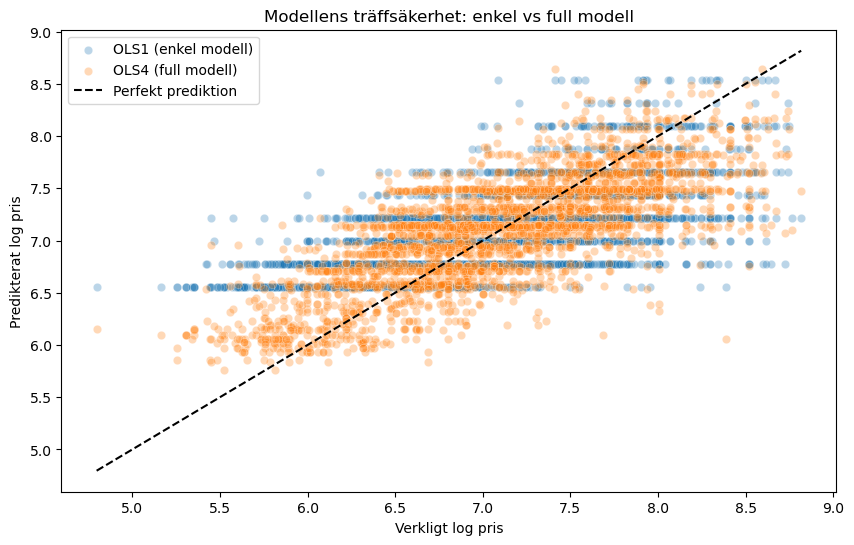

In [50]:
plt.figure(figsize=(10, 6))

# OLS1
sns.scatterplot(
    x=y_true,
    y=y_pred1,
    alpha=0.3,
    label="OLS1 (enkel modell)"
)

# OLS4
sns.scatterplot(
    x=y_true,
    y=y_pred4,
    alpha=0.3,
    label="OLS4 (full modell)"
)

# perfekt linje
x_range = np.linspace(y_true.min(), y_true.max(), 100)
plt.plot(x_range, x_range, color="black", linestyle="--", label="Perfekt prediktion")

plt.xlabel("Verkligt log pris")
plt.ylabel("Predikterat log pris")
plt.title("Modellens träffsäkerhet: enkel vs full modell")
plt.legend()
plt.show()

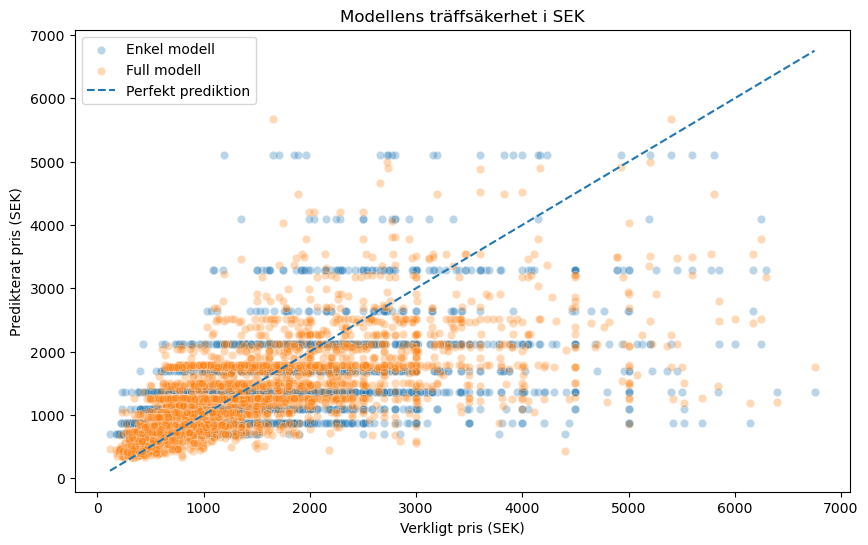

In [51]:
plt.figure(figsize=(10, 6))

# omvandla tillbaka från log → SEK
y_true_sek = np.expm1(y_true)
y_pred1_sek = np.expm1(y_pred1)
y_pred4_sek = np.expm1(y_pred4)

# OLS1
sns.scatterplot(
    x=y_true_sek,
    y=y_pred1_sek,
    alpha=0.3,
    label="Enkel modell"
)

# OLS4
sns.scatterplot(
    x=y_true_sek,
    y=y_pred4_sek,
    alpha=0.3,
    label="Full modell"
)

# perfekt linje
x_range = np.linspace(y_true_sek.min(), y_true_sek.max(), 100)
plt.plot(x_range, x_range, linestyle="--", label="Perfekt prediktion")

plt.xlabel("Verkligt pris (SEK)")
plt.ylabel("Predikterat pris (SEK)")
plt.title("Modellens träffsäkerhet i SEK")
plt.legend()
plt.show()

En jämförelse mellan modellernas prediktioner visar att den fullständiga modellen ligger närmare det faktiska utfallet än den enklare modellen.

Detta visualiserar hur inkluderingen av fler relevanta variabler förbättrar modellens precision.

Ökningen sker när variabler för område, uthyrningstyp och boendetyp successivt inkluderas, vilket visar att prisvariationer inte enbart kan förklaras av storlek, utan påverkas av flera dimensioner.

Särskilt boendetyp (property_group) bidrar med ytterligare förklaringskraft, vilket stödjer tidigare analys av skillnader mellan exempelvis lägenheter och hus.

Trots förbättringen finns fortfarande en betydande spridning kring den perfekta prediktionslinjen, vilket indikerar att ytterligare faktorer påverkar priset.

Min version av Emils roliga uträkning, separera lägenhet / rum

In [53]:
display_df = df.copy()

In [54]:
display_df["predicted_price"] = cleandf["predicted_price"]
display_df["pct_diff"] = cleandf["pct_diff"]

In [55]:
apartments = display_df[
    display_df["room_type"] == "Entire home/apt"
].copy()

print("TOP 10 LÄGENHETS-DEALS:")

print(
    apartments[[
        "name",
        "neighbourhood_cleansed",
        "accommodates",
        "price",
        "predicted_price",
        "pct_diff",
        "listing_url"
    ]]
    .sort_values("pct_diff")
    .head(10)
)

TOP 10 LÄGENHETS-DEALS:
                                               name neighbourhood_cleansed  \
3757                       Stureby(södra stockholm)  Enskede-Årsta-Vantörs   
3203                 Extra övernattnings rum i stan              Norrmalms   
4851      Mysig etta på Mariatorget! Uthyres 1-31/9             Södermalms   
2291                        mycket trevlig lägenhet  Enskede-Årsta-Vantörs   
4229           Rymligt hus med 5 sovrum i Stockholm           Kungsholmens   
4012                                  The Cat Place             Skarpnäcks   
4286                   Small apartment in hipp SOFO             Södermalms   
4299  Vackert, ljust och rymligt hus för 8 personer                 Älvsjö   
4938          Lyxig villa med sjöutsikt & nära city     Hässelby-Vällingby   
3072  Spacious Villa minutes from Central Stockholm  Enskede-Årsta-Vantörs   

      accommodates   price  predicted_price   pct_diff  \
3757             4   232.0       992.051775 -76.614124   
3

In [56]:
rooms = display_df[
    display_df["room_type"] == "Private room"
].copy()

print("\nTOP 10 RUM-DEALS:")

print(
    rooms[[
        "name",
        "neighbourhood_cleansed",
        "accommodates",
        "price",
        "predicted_price",
        "pct_diff",
        "listing_url"
    ]]
    .sort_values("pct_diff")
    .head(10)
)


TOP 10 RUM-DEALS:
                                                   name  \
2271                                          tiny home   
4951           Furnished Room in the Heart of Stockholm   
4157                       Rum i bostadsrätt i Vasastan   
2951            Enkelt rum nära Hornstull utan fönster.   
2042              Bed and breakfast Södermalm Stockholm   
2066  Tiny comfortable room in a house full of stude...   
2541                        Close to central Stockholm.   
69    1/4-Student/Int-ship-room 15 min to Stockholm ...   
2657                      20 m2 Rum uthyres i Stockholm   
3411                    Semi-automatic mini-hotel ( #1)   

      neighbourhood_cleansed  accommodates  price  predicted_price   pct_diff  \
2271  Hägersten-Liljeholmens             1  120.0       515.586040 -76.725514   
4951              Södermalms             2  272.0      1047.589707 -74.035636   
4157              Östermalms             1  299.0       887.045654 -66.292603   
2951   

Och min version av kalkylatorn


In [62]:
def analysera_pris(faktiskt_pris, accommodates, neighbourhood, room_type, property_group):
    # starta med alla feature-kolumner som modellen tränades på
    row = {col: 0.0 for col in features}

    # numeriska värden
    row["accommodates"] = float(accommodates)

    # om du vill kan du sätta typiska defaultvärden för övriga numeriska variabler
    row["bedrooms"] = float(df["bedrooms"].median())
    row["beds"] = float(df["beds"].median())
    row["bathrooms"] = float(df["bathrooms"].median())
    row["review_scores_rating"] = float(df["review_scores_rating"].median())
    row["number_of_reviews"] = float(df["number_of_reviews"].median())
    row["availability_365"] = float(df["availability_365"].median())
    row["minimum_nights"] = float(df["minimum_nights"].median())
    row["has_rating"] = 1.0

    # område
    neighbourhood_col = f"neighbourhood_cleansed_{neighbourhood}"
    if neighbourhood_col in row:
        row[neighbourhood_col] = 1.0

    # room type
    room_col = f"room_type_{room_type}"
    if room_col in row:
        row[room_col] = 1.0

    # property group
    prop_col = f"property_group_{property_group}"
    if prop_col in row:
        row[prop_col] = 1.0

    # bygg dataframe
    X_new = pd.DataFrame([row])

    # lägg till konstant
    X_new = sm.add_constant(X_new, has_constant="add")

    # tvinga exakt samma kolumnordning som modellen tränades på
    X_new = X_new.reindex(columns=model_you.model.exog_names, fill_value=0.0)

    predicted_log = model_you.predict(X_new).iloc[0]
    predicted_price = np.expm1(predicted_log)

    diff_pct = (faktiskt_pris - predicted_price) / predicted_price * 100

    if diff_pct < -20:
        omdome = "Riktigt bra deal!"
    elif diff_pct < 0:
        omdome = "Lite under snittpriset"
    elif diff_pct < 20:
        omdome = "Ungefär rätt pris"
    else:
        omdome = "Överprisat"

    print("=== PRISANALYS ===")
    print(f"Faktiskt pris:   {faktiskt_pris:.0f} SEK")
    print(f"Förväntat pris:  {predicted_price:.0f} SEK")
    print(f"Skillnad:        {diff_pct:+.1f}%")
    print(f"Omdöme:          {omdome}")

def analysera_boende(faktiskt_pris, accommodates, neighbourhood, typ):
    if typ == "apartment":
        room_type = "Entire home/apt"
        property_group = "apartment"
    elif typ == "house":
        room_type = "Entire home/apt"
        property_group = "house"
    elif typ == "room":
        room_type = "Private room"
        property_group = "apartment"
    else:
        raise ValueError("Typ måste vara: apartment, house eller room")

    analysera_pris(
        faktiskt_pris=faktiskt_pris,
        accommodates=accommodates,
        neighbourhood=neighbourhood,
        room_type=room_type,
        property_group=property_group
    )

In [64]:
analysera_boende(
    faktiskt_pris=480,
    accommodates=6,
    neighbourhood="Södermalms",
    typ="apartment"
)

=== PRISANALYS ===
Faktiskt pris:   480 SEK
Förväntat pris:  2189 SEK
Skillnad:        -78.1%
Omdöme:          Riktigt bra deal!


## Kort slutsats

Det som först såg ut som att vissa ytterområden var lika dyra som innerstaden visade sig i själva verket bero på att dessa områden innehåller fler större boenden, särskilt hus. När vi tog hänsyn till boendetyp och uthyrningsform blev prisbilden mer logisk. Våra modeller visar också att både läge, storlek, room type och property type bidrar till att förklara priset, och att en mer genomtänkt variabelindelning förbättrar modellen.